# ATM Cash Demand Forecasting with Google TimesFM

## Industry: Banking Logistics

Banks must forecast ATM cash needs accurately:

- **Refill too early** -> unnecessary logistics cost.
- **Refill too late** -> cash-out events and customer dissatisfaction.

This notebook builds an end-to-end ATM-level forecasting pipeline to predict cash demand for each ATM and convert forecasts into refill decisions.

## Problem Mapping

Input data schema (from dataset):
- `Date`
- `ATM_ID`
- `Total_Withdrawals` (daily withdrawal signal)

Forecast outputs:
- **Tomorrow cash requirement** per ATM
- **Next-week cash requirement** per ATM
- **Holiday demand** impact

Business goals:
- optimize refill trips
- reduce logistics spend
- prevent ATM cash shortages

In [1]:
from __future__ import annotations

import math
import os
import subprocess
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'atm_cash'
RAW_DIR = DATA_DIR / 'raw'
ART_DIR = PROJECT_ROOT / 'artifacts' / 'atm_cash_demand_timesfm'

RAW_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = RAW_DIR / 'atm_cash_management_dataset.csv'

print('Project root:', PROJECT_ROOT)
print('CSV path:', CSV_PATH)
print('Artifacts dir:', ART_DIR)

Project root: /home/ahmad/AI/Github/google-TimesFM-implementation
CSV path: /home/ahmad/AI/Github/google-TimesFM-implementation/data/atm_cash/raw/atm_cash_management_dataset.csv
Artifacts dir: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/atm_cash_demand_timesfm


## 1) Web Data Download (Kaggle)

Dataset:
- https://www.kaggle.com/datasets/zoya77/atm-cash-demand-forecasting-and-management

The cell below uses local cache if present, otherwise downloads via Kaggle CLI.

In [2]:
def ensure_dataset(csv_path: Path) -> Path:
    if csv_path.exists():
        print(f'Found local dataset: {csv_path}')
        return csv_path

    zip_path = RAW_DIR / 'atm-cash-demand-forecasting-and-management.zip'
    cmd = [
        'kaggle', 'datasets', 'download',
        '-d', 'zoya77/atm-cash-demand-forecasting-and-management',
        '-p', str(RAW_DIR),
        '--force',
    ]

    try:
        print('Downloading from Kaggle...')
        subprocess.run(cmd, check=True, capture_output=True, text=True)
    except Exception as exc:
        raise RuntimeError(
            'Kaggle download failed. Configure Kaggle API or place ATM CSV at expected path.'
        ) from exc

    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(RAW_DIR)

    if not csv_path.exists():
        raise FileNotFoundError(f'Expected file not found after download: {csv_path}')

    return csv_path


csv_path = ensure_dataset(CSV_PATH)
csv_path

Found local dataset: /home/ahmad/AI/Github/google-TimesFM-implementation/data/atm_cash/raw/atm_cash_management_dataset.csv


PosixPath('/home/ahmad/AI/Github/google-TimesFM-implementation/data/atm_cash/raw/atm_cash_management_dataset.csv')

## 2) Load and Build ATM Daily Panel

In [3]:
raw = pd.read_csv(csv_path, parse_dates=['Date'])

# Core fields for forecasting and logistics.
use_cols = [
    'ATM_ID', 'Date', 'Total_Withdrawals', 'Holiday_Flag',
    'Special_Event_Flag', 'Previous_Day_Cash_Level'
]
raw = raw[use_cols].copy()

# Aggregate to one row per ATM per day.
daily = (
    raw.groupby(['ATM_ID', 'Date'], as_index=False)
    .agg(
        cash_withdrawn=('Total_Withdrawals', 'sum'),
        holiday_flag=('Holiday_Flag', 'max'),
        special_event_flag=('Special_Event_Flag', 'max'),
        prev_cash_level=('Previous_Day_Cash_Level', 'mean'),
    )
    .sort_values(['ATM_ID', 'Date'])
)

print('Raw rows:', len(raw))
print('Aggregated daily rows:', len(daily))
print('ATMs:', daily['ATM_ID'].nunique())
print('Date range:', daily['Date'].min().date(), '->', daily['Date'].max().date())
daily.head()

Raw rows: 5658
Aggregated daily rows: 5223
ATMs: 50
Date range: 2022-01-01 -> 2024-01-01


,ATM_ID,Date,cash_withdrawn,holiday_flag,special_event_flag,prev_cash_level
0,ATM_0001,2022-01-05,37573,0,1,109776.0
1,ATM_0001,2022-01-13,48156,0,1,113068.0
2,ATM_0001,2022-01-20,24671,0,0,118171.0
3,ATM_0001,2022-01-28,46383,0,0,96931.0
4,ATM_0001,2022-02-01,41972,0,0,83257.0


In [4]:
# Build regular daily series per ATM.
# Since source has sparse dates per ATM, we impute missing days using ATM weekday medians.

def build_regular_series(g: pd.DataFrame) -> pd.DataFrame:
    atm = g['ATM_ID'].iloc[0]
    g = g.sort_values('Date').set_index('Date')
    full_idx = pd.date_range(g.index.min(), g.index.max(), freq='D')
    x = g.reindex(full_idx)
    x['ATM_ID'] = atm

    obs = g['cash_withdrawn'].copy()
    # weekday median imputation fallback to ATM median.
    dow_med = obs.groupby(obs.index.dayofweek).median()
    atm_med = float(obs.median())

    miss = x['cash_withdrawn'].isna()
    if miss.any():
        fill_vals = [
            float(dow_med.get(idx.dayofweek, atm_med))
            for idx in x.index[miss]
        ]
        x.loc[miss, 'cash_withdrawn'] = fill_vals

    x['holiday_flag'] = x['holiday_flag'].fillna(0)
    x['special_event_flag'] = x['special_event_flag'].fillna(0)
    x['prev_cash_level'] = x['prev_cash_level'].ffill().bfill()
    x['prev_cash_level'] = x['prev_cash_level'].fillna(atm_med * 3)

    x = x.reset_index().rename(columns={'index': 'Date'})
    return x

panel = pd.concat([build_regular_series(g) for _, g in daily.groupby('ATM_ID')], ignore_index=True)

# Keep ATMs with enough history for context+horizon training.
atm_len = panel.groupby('ATM_ID')['Date'].size().sort_values(ascending=False)
eligible_atms = atm_len[atm_len >= 180].index.tolist()
panel = panel[panel['ATM_ID'].isin(eligible_atms)].copy()

print('Eligible ATMs:', len(eligible_atms))
print('Panel rows:', len(panel))
print('Panel date range:', panel['Date'].min().date(), '->', panel['Date'].max().date())
panel.head()

Eligible ATMs: 50
Panel rows: 36039
Panel date range: 2022-01-01 -> 2024-01-01


,Date,ATM_ID,cash_withdrawn,holiday_flag,special_event_flag,prev_cash_level
0,2022-01-05,ATM_0001,37573.0,0.0,1.0,109776.0
1,2022-01-06,ATM_0001,49079.5,0.0,0.0,109776.0
2,2022-01-07,ATM_0001,52814.0,0.0,0.0,109776.0
3,2022-01-08,ATM_0001,54457.5,0.0,0.0,109776.0
4,2022-01-09,ATM_0001,47497.0,0.0,0.0,109776.0


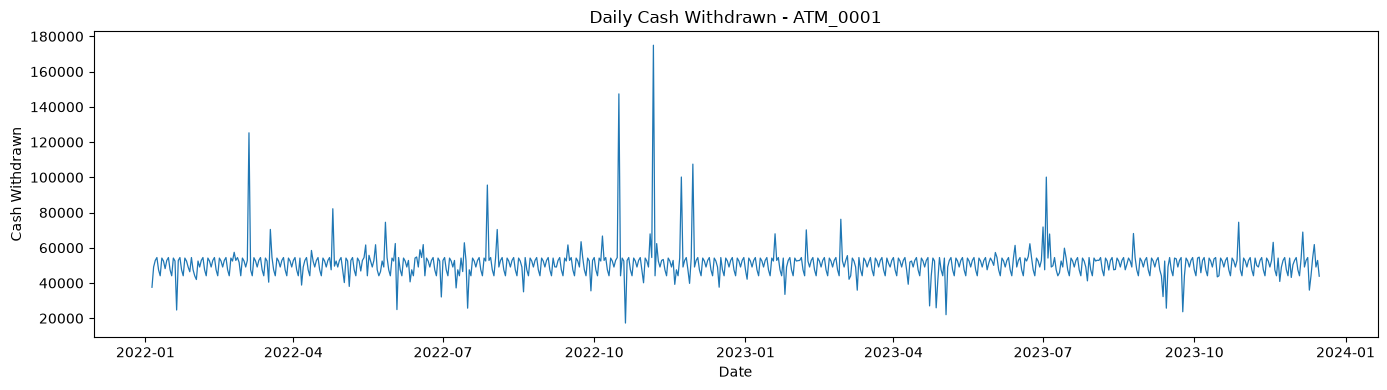

In [5]:
sample_atm = panel['ATM_ID'].iloc[0]
plot_df = panel[panel['ATM_ID'] == sample_atm].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_df['Date'], plot_df['cash_withdrawn'], lw=0.9)
ax.set_title(f'Daily Cash Withdrawn - {sample_atm}')
ax.set_xlabel('Date')
ax.set_ylabel('Cash Withdrawn')
plt.tight_layout()
plt.show()

## 3) Forecast Configuration

We forecast up to 30 days ahead:
- `H=1` tomorrow
- `H=7` next week
- `H=30` monthly / holiday horizon

In [6]:
@dataclass
class Config:
    context_len: int = 120
    max_horizon: int = 30
    eval_horizons: tuple[int, ...] = (1, 7, 30)
    anchor_offsets: tuple[int, ...] = (120, 90, 60, 30)
    per_core_batch_size: int = 8
    xreg_mode: str = 'xreg + timesfm'
    xreg_ridge: float = 1e-3


cfg = Config()
calendar = USFederalHolidayCalendar()

## 4) Load TimesFM

In [7]:
import timesfm

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained('google/timesfm-2.5-200m-pytorch')
fc = timesfm.ForecastConfig(
    max_context=cfg.context_len,
    max_horizon=cfg.max_horizon,
    normalize_inputs=True,
    per_core_batch_size=cfg.per_core_batch_size,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
    return_backcast=True,
)
model.compile(fc)
print('TimesFM compiled.')

TimesFM compiled.


In [8]:
# Helper structures for fast ATM slicing.
series_map: dict[str, pd.DataFrame] = {
    atm: g.sort_values('Date').reset_index(drop=True)
    for atm, g in panel.groupby('ATM_ID')
}


def build_covariates(start_date: pd.Timestamp, context_len: int, horizon: int, holiday_map: dict[pd.Timestamp, float] | None = None) -> dict[str, list[list[float]]]:
    full_dates = pd.date_range(start_date, periods=context_len + horizon, freq='D')
    dow = full_dates.dayofweek.values.astype(np.float32)
    month = full_dates.month.values.astype(np.float32)

    # Federal holidays + optional dataset holiday map.
    fed_holidays = set(calendar.holidays(start=full_dates.min(), end=full_dates.max()))
    is_holiday = np.array([1.0 if d in fed_holidays else 0.0 for d in full_dates], dtype=np.float32)

    if holiday_map is not None:
        hm = np.array([holiday_map.get(pd.Timestamp(d).normalize(), 0.0) for d in full_dates], dtype=np.float32)
        is_holiday = np.maximum(is_holiday, hm)

    return {
        'dow_sin': [np.sin(2 * np.pi * dow / 7).astype(np.float32).tolist()],
        'dow_cos': [np.cos(2 * np.pi * dow / 7).astype(np.float32).tolist()],
        'month_sin': [np.sin(2 * np.pi * month / 12).astype(np.float32).tolist()],
        'month_cos': [np.cos(2 * np.pi * month / 12).astype(np.float32).tolist()],
        'is_weekend': [(dow >= 5).astype(np.float32).tolist()],
        'is_holiday': [is_holiday.tolist()],
    }


def wmape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-8))

## 5) Backtest: TimesFM vs Baselines (ATM-level)

Baselines:
- `naive_last` (persistence)
- `seasonal7` (weekly repeat)

In [9]:
metric_rows = []

for offset in cfg.anchor_offsets:
    inputs = []
    dyn_covs = {'dow_sin': [], 'dow_cos': [], 'month_sin': [], 'month_cos': [], 'is_weekend': [], 'is_holiday': []}
    combos = []

    for atm, ts in series_map.items():
        n = len(ts)
        end = n - 1 - offset
        if end - cfg.context_len + 1 < 0 or end + cfg.max_horizon >= n:
            continue

        context = ts['cash_withdrawn'].iloc[end - cfg.context_len + 1 : end + 1].to_numpy(np.float32)
        start_date = pd.Timestamp(ts['Date'].iloc[end - cfg.context_len + 1])

        # map known holiday flag by date for this ATM context/history
        holiday_map = {
            pd.Timestamp(d).normalize(): float(h)
            for d, h in zip(ts['Date'], ts['holiday_flag'])
        }
        cov = build_covariates(start_date, cfg.context_len, cfg.max_horizon, holiday_map=holiday_map)

        inputs.append(context)
        for k in dyn_covs:
            dyn_covs[k].append(cov[k][0])

        future = ts['cash_withdrawn'].iloc[end + 1 : end + cfg.max_horizon + 1].to_numpy(np.float32)
        combos.append((atm, future, context[-1], context[-7:]))

    if not inputs:
        continue

    try:
        point, _ = model.forecast_with_covariates(
            inputs=inputs,
            dynamic_numerical_covariates=dyn_covs,
            xreg_mode=cfg.xreg_mode,
            ridge=cfg.xreg_ridge,
        )
        pred_batch = np.asarray(point, dtype=np.float32)
    except Exception:
        point, _ = model.forecast(horizon=cfg.max_horizon, inputs=inputs)
        pred_batch = np.asarray(point, dtype=np.float32)

    pred_batch = np.clip(pred_batch, 0.0, None)

    for i, (atm, y_true, last_val, last7) in enumerate(combos):
        pred_tfm = pred_batch[i, : cfg.max_horizon]
        pred_naive = np.repeat(last_val, cfg.max_horizon)
        pred_seasonal7 = np.tile(last7, math.ceil(cfg.max_horizon / 7))[: cfg.max_horizon]

        for hz in cfg.eval_horizons:
            y = y_true[:hz]
            for name, p in {
                'timesfm': pred_tfm[:hz],
                'naive_last': pred_naive[:hz],
                'seasonal7': pred_seasonal7[:hz],
            }.items():
                metric_rows.append(
                    {
                        'atm_id': atm,
                        'anchor_offset': offset,
                        'horizon_days': hz,
                        'model': name,
                        'mae': mean_absolute_error(y, p),
                        'rmse': mean_squared_error(y, p) ** 0.5,
                        'wmape': wmape(y, p),
                    }
                )

metrics = (
    pd.DataFrame(metric_rows)
    .groupby(['horizon_days', 'model'], as_index=False)[['mae', 'rmse', 'wmape']]
    .mean()
    .sort_values(['horizon_days', 'rmse'])
)
metrics

,horizon_days,model,mae,rmse,wmape
2,1,timesfm,2712.377031,2712.377016,0.055282
1,1,seasonal7,3992.670000,3992.670011,0.080055
0,1,naive_last,10222.957500,10222.957484,0.212077
5,7,timesfm,3251.409784,5461.045876,0.061924
4,7,seasonal7,4209.887134,8542.725620,0.080318
3,7,naive_last,9653.403885,11957.180248,0.186456
8,30,timesfm,3461.979439,7564.950939,0.066326
7,30,seasonal7,4443.227677,10382.059446,0.085185
6,30,naive_last,9805.325189,12898.147236,0.188592


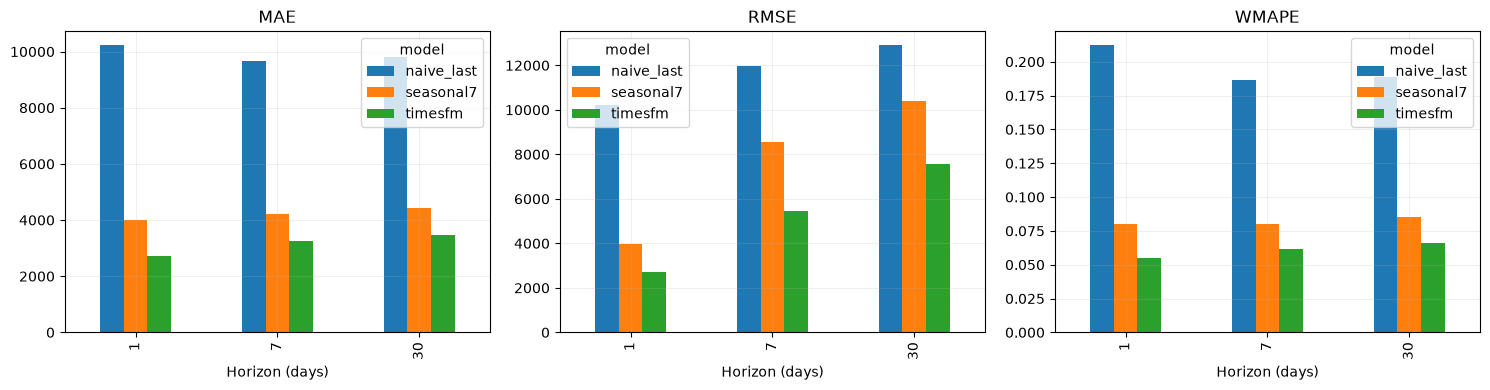

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, metric in zip(axes, ['mae', 'rmse', 'wmape']):
    p = metrics.pivot(index='horizon_days', columns='model', values=metric)
    p.plot(kind='bar', ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel('Horizon (days)')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6) Final Forecast for Each ATM (Tomorrow, Next Week, Holidays)

In [11]:
# Batch forecast from latest available date per ATM.
inputs = []
dyn_covs = {'dow_sin': [], 'dow_cos': [], 'month_sin': [], 'month_cos': [], 'is_weekend': [], 'is_holiday': []}
meta = []

for atm, ts in series_map.items():
    if len(ts) < cfg.context_len + cfg.max_horizon:
        continue

    context = ts['cash_withdrawn'].iloc[-cfg.context_len:].to_numpy(np.float32)
    start_date = pd.Timestamp(ts['Date'].iloc[-cfg.context_len])
    anchor_date = pd.Timestamp(ts['Date'].iloc[-1])

    holiday_map = {
        pd.Timestamp(d).normalize(): float(h)
        for d, h in zip(ts['Date'], ts['holiday_flag'])
    }
    cov = build_covariates(start_date, cfg.context_len, cfg.max_horizon, holiday_map=holiday_map)

    inputs.append(context)
    for k in dyn_covs:
        dyn_covs[k].append(cov[k][0])
    meta.append((atm, anchor_date, float(ts['prev_cash_level'].iloc[-1]), float(ts['cash_withdrawn'].median())))

try:
    point, quant = model.forecast_with_covariates(
        inputs=inputs,
        dynamic_numerical_covariates=dyn_covs,
        xreg_mode=cfg.xreg_mode,
        ridge=cfg.xreg_ridge,
    )
    point_np = np.asarray(point, dtype=np.float32)
    quant_np = np.asarray(quant, dtype=np.float32)
except Exception:
    point, quant = model.forecast(horizon=cfg.max_horizon, inputs=inputs)
    point_np = np.asarray(point, dtype=np.float32)
    quant_np = np.asarray(quant, dtype=np.float32)

point_np = np.clip(point_np, 0.0, None)
quant_np = np.clip(quant_np, 0.0, None)

rows = []
for i, (atm, anchor_date, prev_cash, med_withdraw) in enumerate(meta):
    fut_dates = pd.date_range(anchor_date + pd.Timedelta(days=1), periods=cfg.max_horizon, freq='D')
    for h, d in enumerate(fut_dates, start=1):
        rows.append(
            {
                'ATM_ID': atm,
                'forecast_date': d,
                'horizon_day': h,
                'cash_p50': float(point_np[i, h - 1]),
                'cash_q10': float(quant_np[i, h - 1, 1]),
                'cash_q90': float(quant_np[i, h - 1, 9]),
                'last_known_cash_level': prev_cash,
                'atm_median_withdrawal': med_withdraw,
            }
        )

forecast_df = pd.DataFrame(rows)

# Tomorrow and next-week requirements.
tomorrow_forecast = forecast_df[forecast_df['horizon_day'] == 1].copy()
next_week_requirement = (
    forecast_df[forecast_df['horizon_day'] <= 7]
    .groupby('ATM_ID', as_index=False)
    .agg(
        week_cash_p50=('cash_p50', 'sum'),
        week_cash_q90=('cash_q90', 'sum'),
    )
)

# Holiday demand in forecast window.
us_holidays = set(calendar.holidays(start=forecast_df['forecast_date'].min(), end=forecast_df['forecast_date'].max()))
holiday_forecast = forecast_df[forecast_df['forecast_date'].isin(us_holidays)].copy()

print('Tomorrow forecast rows:', len(tomorrow_forecast))
print('Next-week requirement rows:', len(next_week_requirement))
print('Holiday forecast rows:', len(holiday_forecast))

next_week_requirement.head()

Tomorrow forecast rows: 50
Next-week requirement rows: 50
Holiday forecast rows: 99


,ATM_ID,week_cash_p50,week_cash_q90
0,ATM_0001,344301.769531,384731.183594
1,ATM_0002,343937.453125,376268.695312
2,ATM_0003,346677.046875,375862.382812
3,ATM_0004,342506.703125,378392.613281
4,ATM_0005,392319.550781,460147.089844


## 7) Refill Policy Simulation (Logistics Optimization)

We compare two policies over next 7 days:

- **Baseline policy:** refill every 2 days to capacity.
- **Forecast policy:** refill only when projected end-of-day cash (using `q90`) falls below safety stock.

Outputs:
- refill trips
- shortage events
- recommended refill plan

In [12]:
week_df = forecast_df[forecast_df['horizon_day'] <= 7].copy()

# ATM-level parameters
atm_params = (
    week_df.groupby('ATM_ID', as_index=False)
    .agg(
        initial_cash=('last_known_cash_level', 'first'),
        median_withdrawal=('atm_median_withdrawal', 'first'),
    )
)

# Capacity heuristic from observed cash level + demand profile.
atm_params['capacity'] = np.maximum(
    atm_params['initial_cash'] * 1.15,
    atm_params['median_withdrawal'] * 6.0,
)
atm_params['safety_stock'] = atm_params['median_withdrawal'] * 1.5


def simulate_policy(policy_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    plan_rows = []
    summary_rows = []

    for _, p in atm_params.iterrows():
        atm = p['ATM_ID']
        capacity = float(p['capacity'])
        safety = float(p['safety_stock'])
        cash = float(min(p['initial_cash'], capacity))

        sub = week_df[week_df['ATM_ID'] == atm].sort_values('horizon_day')

        trips = 0
        shortages = 0

        for r in sub.itertuples(index=False):
            date = r.forecast_date
            day = int(r.horizon_day)
            w_p50 = float(r.cash_p50)
            w_q90 = float(r.cash_q90)

            refill_amt = 0.0

            if policy_name == 'baseline_every2days':
                if day in (1, 3, 5, 7):
                    refill_amt = max(0.0, capacity - cash)
            elif policy_name == 'forecast_triggered':
                projected_eod = cash - w_q90
                if projected_eod < safety:
                    refill_amt = max(0.0, capacity - cash)
            else:
                raise ValueError('Unknown policy')

            if refill_amt > 0:
                trips += 1
                cash += refill_amt
                plan_rows.append(
                    {
                        'policy': policy_name,
                        'ATM_ID': atm,
                        'date': date,
                        'refill_amount': refill_amt,
                        'cash_after_refill': cash,
                    }
                )

            # Realization proxy for simulation: p50 demand.
            cash -= w_p50
            if cash < 0:
                shortages += 1
                cash = 0.0

        summary_rows.append(
            {
                'policy': policy_name,
                'ATM_ID': atm,
                'trips': trips,
                'shortage_days': shortages,
            }
        )

    return pd.DataFrame(plan_rows), pd.DataFrame(summary_rows)


plan_base, summary_base = simulate_policy('baseline_every2days')
plan_opt, summary_opt = simulate_policy('forecast_triggered')

logistics_summary = (
    pd.concat([summary_base, summary_opt], ignore_index=True)
    .groupby('policy', as_index=False)[['trips', 'shortage_days']]
    .sum()
)

refill_plan = plan_opt.copy().sort_values(['date', 'ATM_ID']).reset_index(drop=True)

logistics_summary

,policy,trips,shortage_days
0,baseline_every2days,200,0
1,forecast_triggered,100,0


In [13]:
# Business KPI comparison
base = logistics_summary[logistics_summary['policy'] == 'baseline_every2days'].iloc[0]
opt = logistics_summary[logistics_summary['policy'] == 'forecast_triggered'].iloc[0]

trip_reduction = (base['trips'] - opt['trips']) / max(base['trips'], 1)
shortage_reduction = (base['shortage_days'] - opt['shortage_days']) / max(base['shortage_days'], 1)

print(f"Baseline trips: {int(base['trips'])}")
print(f"Forecast-policy trips: {int(opt['trips'])}")
print(f"Trip reduction: {trip_reduction:.1%}")
print(f"Baseline shortage days: {int(base['shortage_days'])}")
print(f"Forecast-policy shortage days: {int(opt['shortage_days'])}")
print(f"Shortage reduction: {shortage_reduction:.1%}")

refill_plan.head(20)

Baseline trips: 200
Forecast-policy trips: 100
Trip reduction: 50.0%
Baseline shortage days: 0
Forecast-policy shortage days: 0
Shortage reduction: 0.0%


,policy,ATM_ID,date,refill_amount,cash_after_refill
0,forecast_triggered,ATM_0034,2023-12-09,221865.000000,326154.0
1,forecast_triggered,ATM_0034,2023-12-13,198821.109375,326154.0
2,forecast_triggered,ATM_0001,2023-12-17,209288.000000,314862.0
3,forecast_triggered,ATM_0036,2023-12-17,182704.000000,317586.0
4,forecast_triggered,ATM_0026,2023-12-18,218440.000000,291276.0
5,forecast_triggered,ATM_0046,2023-12-19,227152.000000,323925.0
6,forecast_triggered,ATM_0001,2023-12-21,188982.281250,314862.0
7,forecast_triggered,ATM_0026,2023-12-21,157637.347656,291276.0
8,forecast_triggered,ATM_0036,2023-12-21,211474.402344,317586.0
9,forecast_triggered,ATM_0003,2023-12-23,174466.000000,293076.0


In [14]:
metrics_path = ART_DIR / 'backtest_metrics.csv'
forecast_path = ART_DIR / 'forecast_next_30_days.csv'
tomorrow_path = ART_DIR / 'tomorrow_cash_requirement.csv'
week_path = ART_DIR / 'next_week_cash_requirement.csv'
holiday_path = ART_DIR / 'holiday_demand_forecast.csv'
refill_plan_path = ART_DIR / 'refill_plan_forecast_policy.csv'
logistics_summary_path = ART_DIR / 'logistics_summary.csv'

metrics.to_csv(metrics_path, index=False)
forecast_df.to_csv(forecast_path, index=False)
tomorrow_forecast.to_csv(tomorrow_path, index=False)
next_week_requirement.to_csv(week_path, index=False)
holiday_forecast.to_csv(holiday_path, index=False)
refill_plan.to_csv(refill_plan_path, index=False)
logistics_summary.to_csv(logistics_summary_path, index=False)

print('Saved:', metrics_path)
print('Saved:', forecast_path)
print('Saved:', tomorrow_path)
print('Saved:', week_path)
print('Saved:', holiday_path)
print('Saved:', refill_plan_path)
print('Saved:', logistics_summary_path)

Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/atm_cash_demand_timesfm/backtest_metrics.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/atm_cash_demand_timesfm/forecast_next_30_days.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/atm_cash_demand_timesfm/tomorrow_cash_requirement.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/atm_cash_demand_timesfm/next_week_cash_requirement.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/atm_cash_demand_timesfm/holiday_demand_forecast.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/atm_cash_demand_timesfm/refill_plan_forecast_policy.csv
Saved: /home/ahmad/AI/Github/google-TimesFM-implementation/artifacts/atm_cash_demand_timesfm/logistics_summary.csv


## Final Deliverables

This notebook provides ATM-level outputs for:

1. **Tomorrow cash demand** (`H=1`) for refill dispatch planning.
2. **Next-week cash requirement** (`H=7`) for route and cash-loading decisions.
3. **Holiday demand forecasts** to prepare for demand spikes.
4. **Forecast-driven refill policy** that balances trip cost and shortage risk.

For production, run this pipeline daily and push outputs into cash logistics routing systems.